In [1]:
%load_ext autoreload
%autoreload 2

# Trade Strategy 20250419

## Description
Combine various individual strategies and assets to create a portfolio.

## Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from utils.data_fetcher import TickerPriceDataFetcher
import os
from indicators.volatility import calculate_atr, calculate_forward_vol
from indicators.returns import calculate_returns, calculate_forward_returns
from utils.helpers import PercentileScaler
import datetime
from sklearn.linear_model import LinearRegression
from utils.backtester import BackTester
import backtrader as bt
from sklearn.metrics import r2_score

Warning - Certain functionality 
             requires requests_html, which is not installed.
             
             Install using: 
             pip install requests_html
             
             After installation, you may have to restart your Python session.


c:\Users\alexr\AlgoTester\utils\data_fetcher.py:19: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## Utils

### Helpers

In [3]:
def normalize_weights(weights):
    total_weight = sum(weights.values())
    normalized_weights = {ticker: weight / total_weight for ticker, weight in weights.items()}
    return normalized_weights


### Asset Class

In [4]:
class Asset:
    def __init__(
        self, 
        ticker,
        vol_ticker=None,
        lookforward_period=21,
        lookback_periods=[21, 100, 200, 252],
        rebalance_period=21,
        atr_period=21,
        verbose=True,
    ):
        # Tickers and Parameters
        self.ticker = ticker
        self.vol_ticker = vol_ticker
        self.lookforward_period = lookforward_period
        self.lookback_periods = lookback_periods
        self.rebalance_period = rebalance_period
        self.atr_period = atr_period
        self.strategy_returns = dict()
        self.verbose=verbose

    
    def fetch_price_data(self, ticker):
        """
        Fetch price data from the price_data folder as DataFrame.
        """
        if ticker is None:
            return None
        price_data_folder = './data/raw/price/'
        try:
            price_data_file = [f for f in os.listdir(price_data_folder) if f.split('_')[0] == ticker][0]
        except:
            print(f'No price data for {ticker}')
            return None
        return pd.read_pickle(os.path.join(price_data_folder, price_data_file)).copy()
    

    def process_data(self):
        # DataFrames
        self.raw_price_data = self.fetch_price_data(self.ticker)
        self.data = self.fetch_price_data(self.ticker)
        self.vol_data = self.fetch_price_data(self.vol_ticker)

        # Live Trading
        self.current_date = self.raw_price_data.index.to_list()[-1]
        self.current_price = self.raw_price_data['close'].to_list()[-1]

        # Calculate indicators
        self.data['returns'] = self.data['close'].pct_change()
        self.data['vol_forward'] = calculate_forward_vol(self.data, self.lookforward_period)
        self.data['ret_forward'] = calculate_forward_returns(self.data, self.lookforward_period)
        self.data['ATR'] = calculate_atr(self.data, self.atr_period)
        self.data['var_forward'] = self.data['vol_forward'] ** 2
        if self.vol_data is not None:
            self.data['VIX'] = self.vol_data['close']

        # Percentile Scaler for Variance
        self.var_scaler = PercentileScaler()
        self.var_scaler.fit(self.data['var_forward'].dropna().values.reshape(-1, 1))
        var_scaled = self.var_scaler.transform(self.data['var_forward'].values.reshape(-1, 1))
        self.data['vol_scaling_factor'] = 1 - var_scaled

        # Forecast Volatility
        df_train = self.data.dropna().copy()
        y = df_train['vol_forward'].to_numpy()
        X = []
        input_cols = []
        if 'VIX' in df_train.columns:
            X.append(df_train['VIX'].to_numpy().reshape(-1, 1))
            input_cols.append('VIX')
        if 'ATR' in df_train.columns:
            X.append(df_train['ATR'].to_numpy().reshape(-1, 1))
            input_cols.append('ATR')
        X = np.concatenate(X, axis=1)
        self.vol_forecast_model = LinearRegression()
        self.vol_forecast_model.fit(X, y)
        y_true = y
        y_pred = self.vol_forecast_model.predict(X)
        r2 = r2_score(y_true, y_pred)

        for i, r in tqdm(self.data.iterrows(), total=self.data.shape[0]):
            if 'VIX' in input_cols and np.isnan(r['VIX']):
                self.data.loc[i, 'vol_forward'] = np.nan
                continue
            if 'ATR' in input_cols and np.isnan(r['ATR']):
                self.data.loc[i, 'vol_forward'] = np.nan
                continue
            
            self.data.loc[i, 'vol_forward_pred'] = self.vol_forecast_model.predict([[r[f] for f in input_cols]])
        self.data['var_forward_pred'] = self.data['vol_forward_pred'] ** 2
        self.data['vol_scaling_factor_pred'] = 1 - self.var_scaler.transform(self.data['var_forward_pred'].values.reshape(-1, 1))

        if self.verbose:
            df = self.data[['vol_scaling_factor', 'vol_scaling_factor_pred']].dropna()
            y_true = df['vol_scaling_factor'].to_numpy()
            y_pred = df['vol_scaling_factor_pred'].to_numpy()
            plt.scatter(y_true, y_pred)
            # Plot the perfect prediction line (y_true = y_pred)
            perfect_line = np.linspace(min(y_true), max(y_true), 100)
            plt.plot(perfect_line, perfect_line, 'r--', label='Perfect prediction')

            # Add best fit line for the actual predictions
            # (This shows how well predictions match true values)
            coef = np.polyfit(y_true, y_pred, 1, cov=False)
            best_fit = np.poly1d(coef)
            plt.plot(y_true, best_fit(y_true), color='orange', label=f'Best fit line (R² = {r2:.2f})')
            plt.xlabel('Actual Volatility')
            plt.ylabel('Predicted Volatility')
            plt.legend()
            plt.show()

            


### Strategy
#### TrendVol Strategy (Single Asset)

In [5]:
from strategies.base import BaseStrategy

class TrendVol(BaseStrategy):

    params = (
        ('rebalance_period', 21),
        ('lookback_periods', [21, 100, 200, 252]),
        ('df_vol', dict()),
        ('vol_scaling_col', 'vol_scaling_percentile'),
    )

    def __init__(self):
        super().__init__()

        # Track rebalance interval
        self.rebalance_day = 0

        # Trend identification
        self.trend = dict()
        self.lookback_weights = {}
        for period in self.p.lookback_periods:
            self.trend[period] = self.data.close - bt.indicators.SMA(self.data.close, period=period)
            self.lookback_weights[period] = 1 / len(self.p.lookback_periods)

        # Vol scaling
        self.df_vol = self.p.df_vol
        if self.p.vol_scaling_col not in self.df_vol.columns:
            raise ValueError(f"df_vol must have column {self.p.vol_scaling_col}")
        
        
    def next(self):
        super().next()
        if self.rebalance_day % self.p.rebalance_period == 0:
            current_position = self.getposition(self.data).size
            current_date = self.datetime.date()

            # Trend factor
            trend_factor = 0.0
            for period in self.p.lookback_periods:
                if self.trend[period][0] > 0:
                    trend_factor += self.lookback_weights[period]
                # else:
                #     trend_factor -= 0.5 * self.lookback_weights[period]
            
            # Vol scaling factor
            vol_scaling_factor = self.df_vol.loc[self.df_vol.index == pd.to_datetime(current_date), self.p.vol_scaling_col].values[0]
            
            target_position = np.min([trend_factor, vol_scaling_factor]) * (self.broker.getvalue() / self.data.close[0])
            self._submit_order(self.data._name, target_position - current_position, self.data.close[0])
        
        self.rebalance_day += 1

## Parameters

In [6]:
capital = 66069 + 1500
leverage = 3
lookforward_period = 21
lookback_periods=[21, 100, 200, 252]
rebalance_period=21
atr_period = 21
covariance_matrix_lookback = 252

asset_configs = [
    {
        'ticker': 'SPY',
        'vol_ticker': '^VIX',
    },
    {
        'ticker': 'GLD',
        'vol_ticker': '^GVZ',
    },
    {
        'ticker': 'TLT',
        # 'vol_ticker': '^VXTLT',
    },
    # {
    #     'ticker': 'EEM',
    #     # 'vol_ticker': '^VXIE',
    # },
    # {'ticker': 'LQD'},
    # {'ticker': 'DBA'},
    # {'ticker': 'DBB'},
]

current_date = datetime.datetime.now().date()
current_date = current_date.strftime("%Y%m%d")

## Load Data

In [7]:
tickers_to_fetch = ['IB01.L', 'SPY', 'TLT', 'GLD', '^VIX', '^GVZ', 'PPLT', 'URA']
assets = dict()
for config in asset_configs:
    assets[config['ticker']] = Asset(
        ticker=config['ticker'],
        vol_ticker=config.get('vol_ticker', None),
        lookforward_period=lookforward_period,
        lookback_periods=lookback_periods,
        rebalance_period=rebalance_period,
        atr_period=atr_period,
    )

    # tickers_to_fetch.append(config['ticker'])
    # if config.get('vol_ticker', None):
    #     tickers_to_fetch.append(config['vol_ticker'])

fetcher = TickerPriceDataFetcher()
price_data = fetcher.load_data(ticker_list=tickers_to_fetch)
cash_asset = {'ticker': 'IB01.L', 'data': price_data['IB01.L']}


2025-05-21 22:13:27,207 - utils.data_fetcher - INFO - Loading data for ['IB01.L', 'SPY', 'TLT', 'GLD', '^VIX', '^GVZ', 'PPLT', 'URA']
2025-05-21 22:13:27,209 - utils.data_fetcher - INFO - Fetching data for IB01.L with yfinance
2025-05-21 22:13:27,644 - utils.data_fetcher - ERROR - No existing file for IB01.L
2025-05-21 22:13:27,647 - utils.data_fetcher - INFO - Data for SPY already exists
2025-05-21 22:13:27,648 - utils.data_fetcher - INFO - Data for TLT already exists
2025-05-21 22:13:27,650 - utils.data_fetcher - INFO - Data for GLD already exists
2025-05-21 22:13:27,651 - utils.data_fetcher - INFO - Data for ^VIX already exists
2025-05-21 22:13:27,652 - utils.data_fetcher - INFO - Data for ^GVZ already exists
2025-05-21 22:13:27,653 - utils.data_fetcher - INFO - Data for PPLT already exists
2025-05-21 22:13:27,663 - utils.data_fetcher - INFO - Data for URA already exists


## Preprocessing

SPY


  0%|          | 0/8134 [00:00<?, ?it/s]

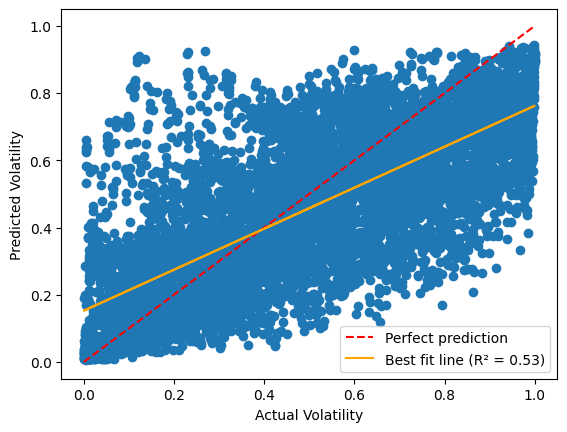

GLD


  0%|          | 0/5159 [00:00<?, ?it/s]

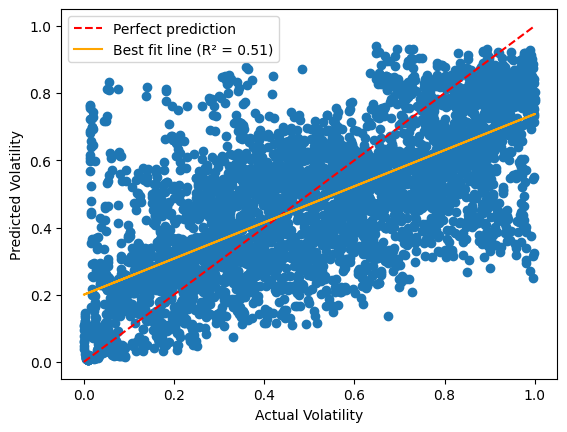

TLT


  0%|          | 0/5741 [00:00<?, ?it/s]

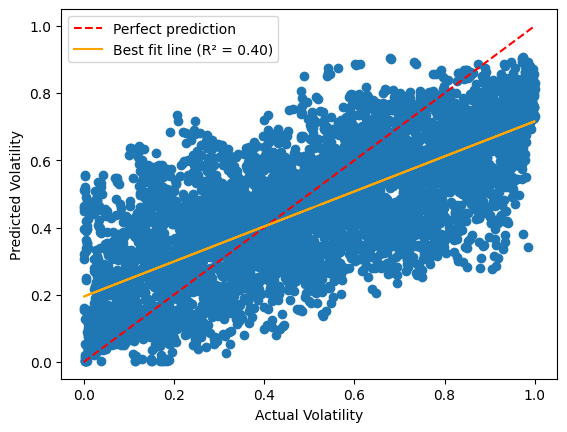

In [8]:
for ticker in assets:
    print(ticker)
    assets[ticker].process_data()


## Backtest Strategy
### Single Asset


-------------------------------------------
SPY


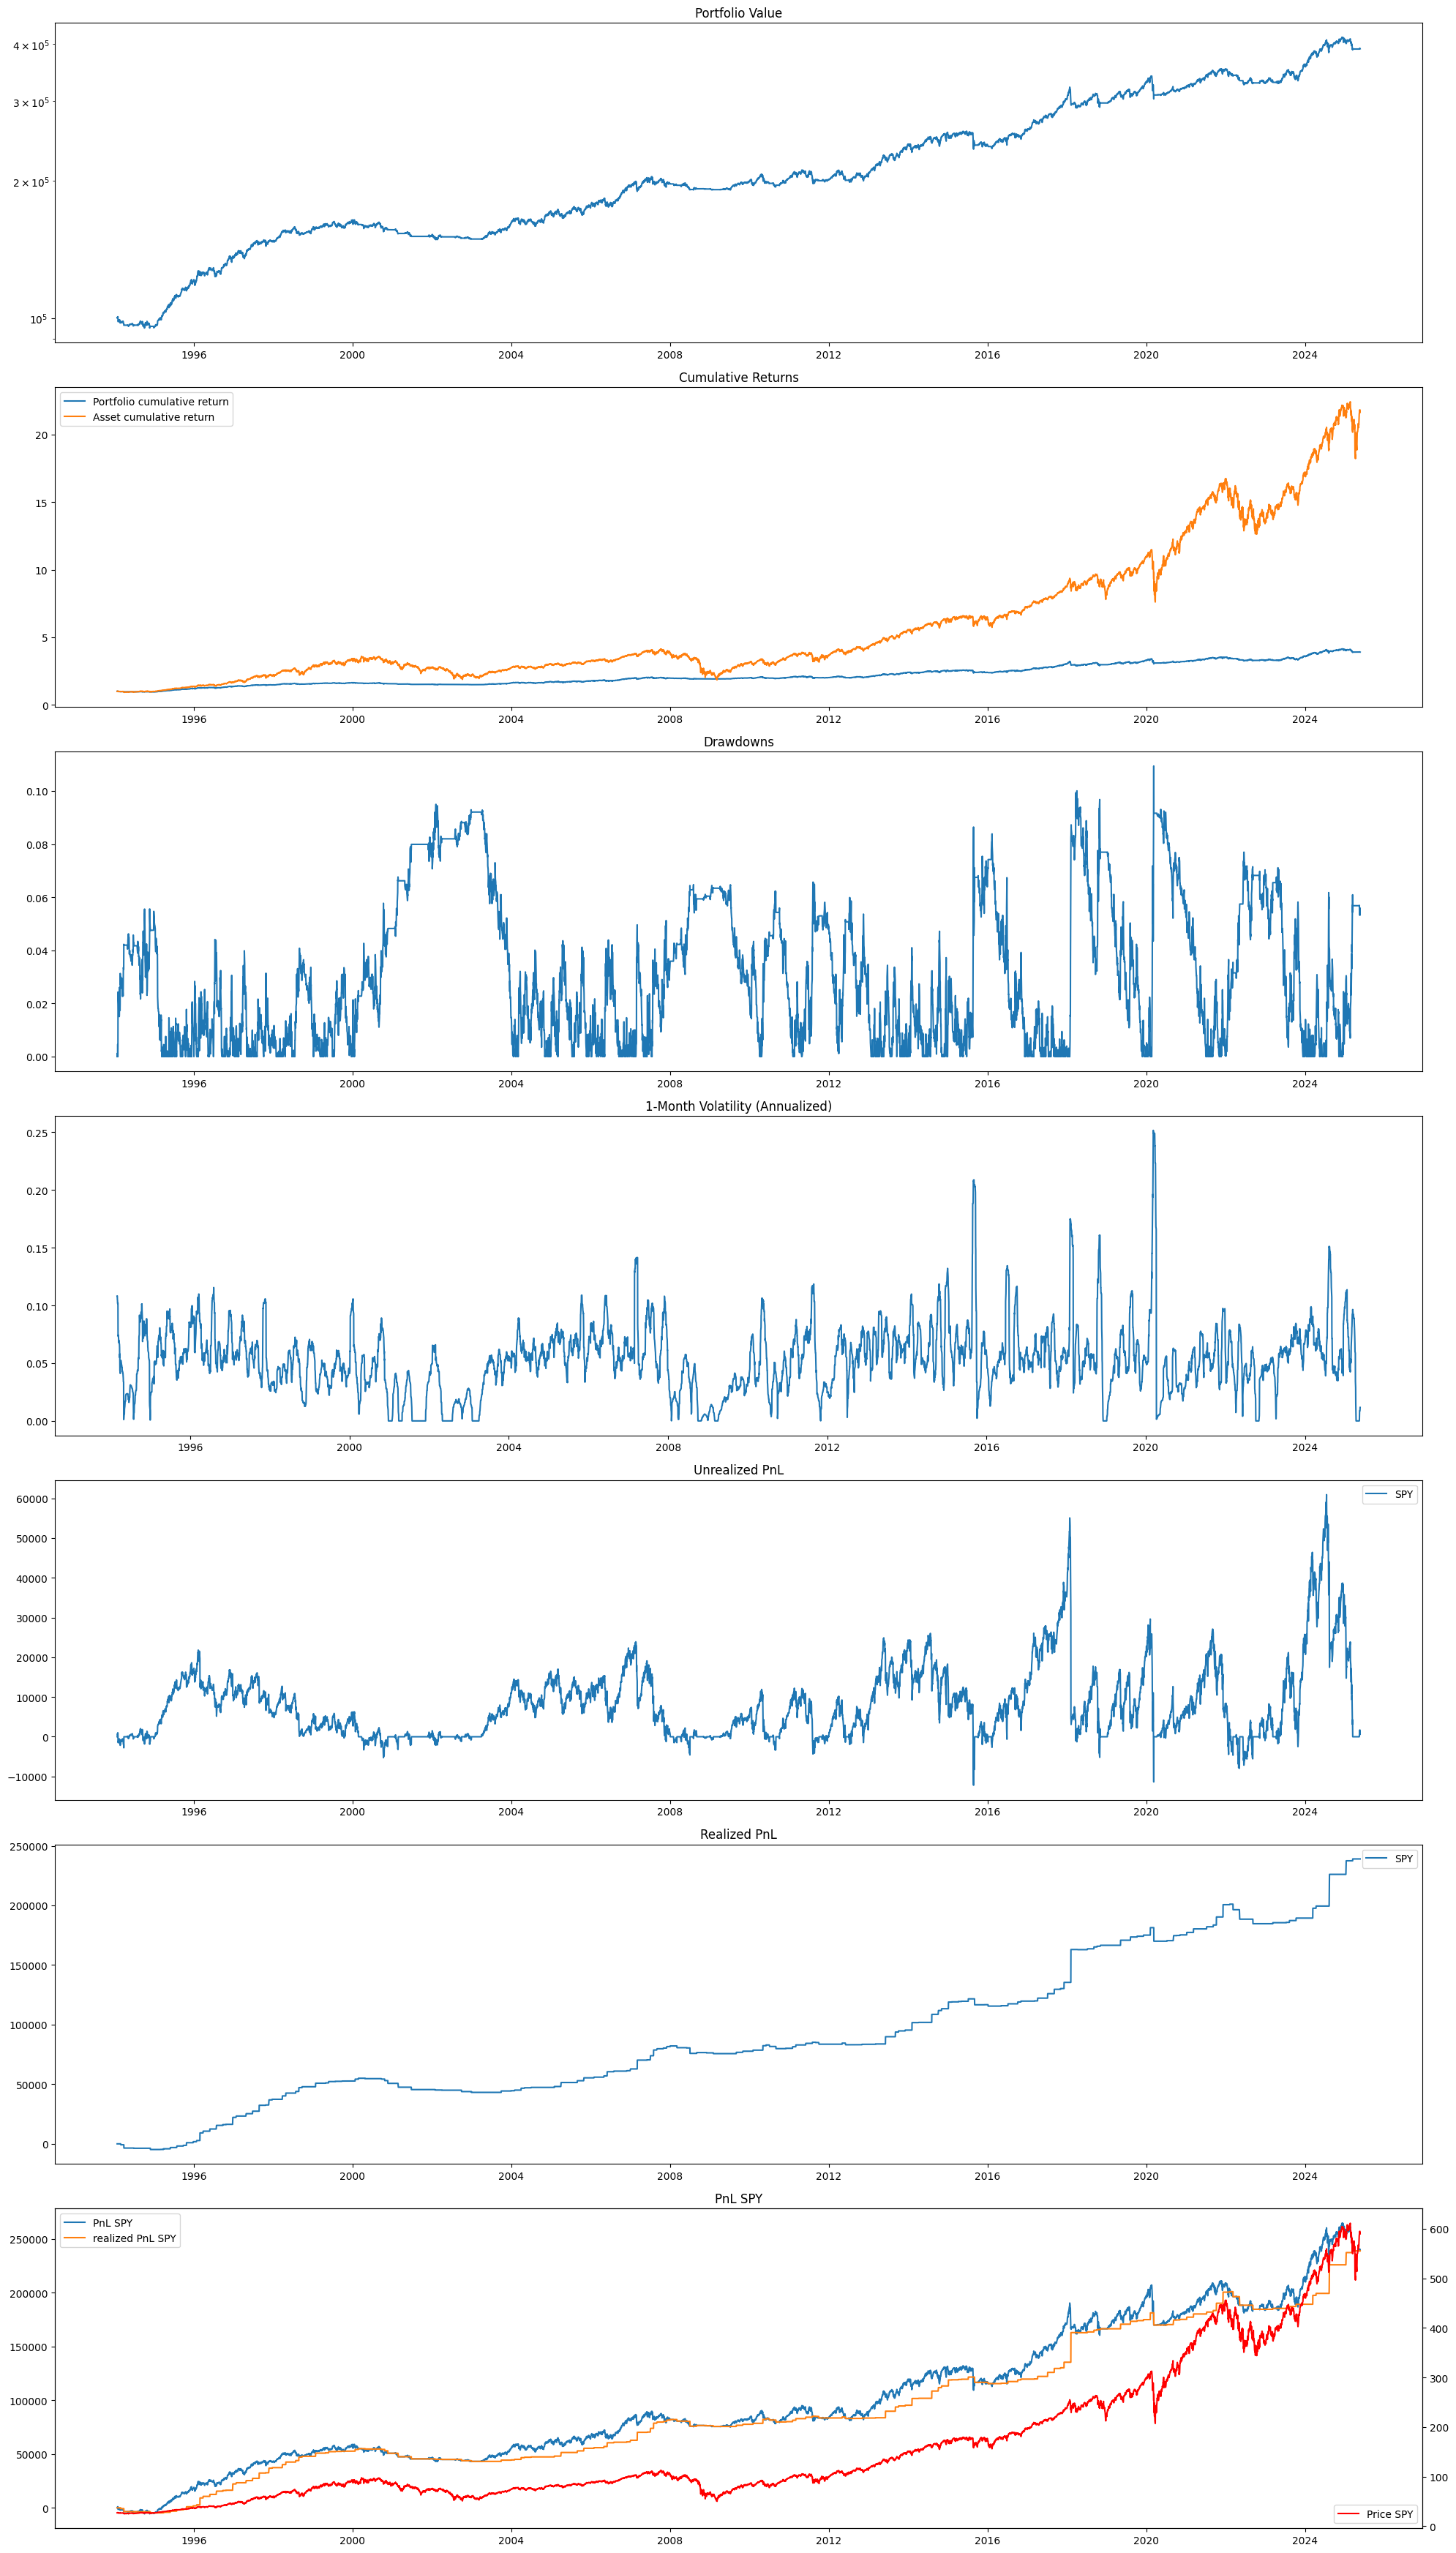

cagr: 0.04
volatility: 0.06
sharpe: 0.73
max_drawdown: 0.11
cumulative_returns: 2.91

-------------------------------------------
GLD


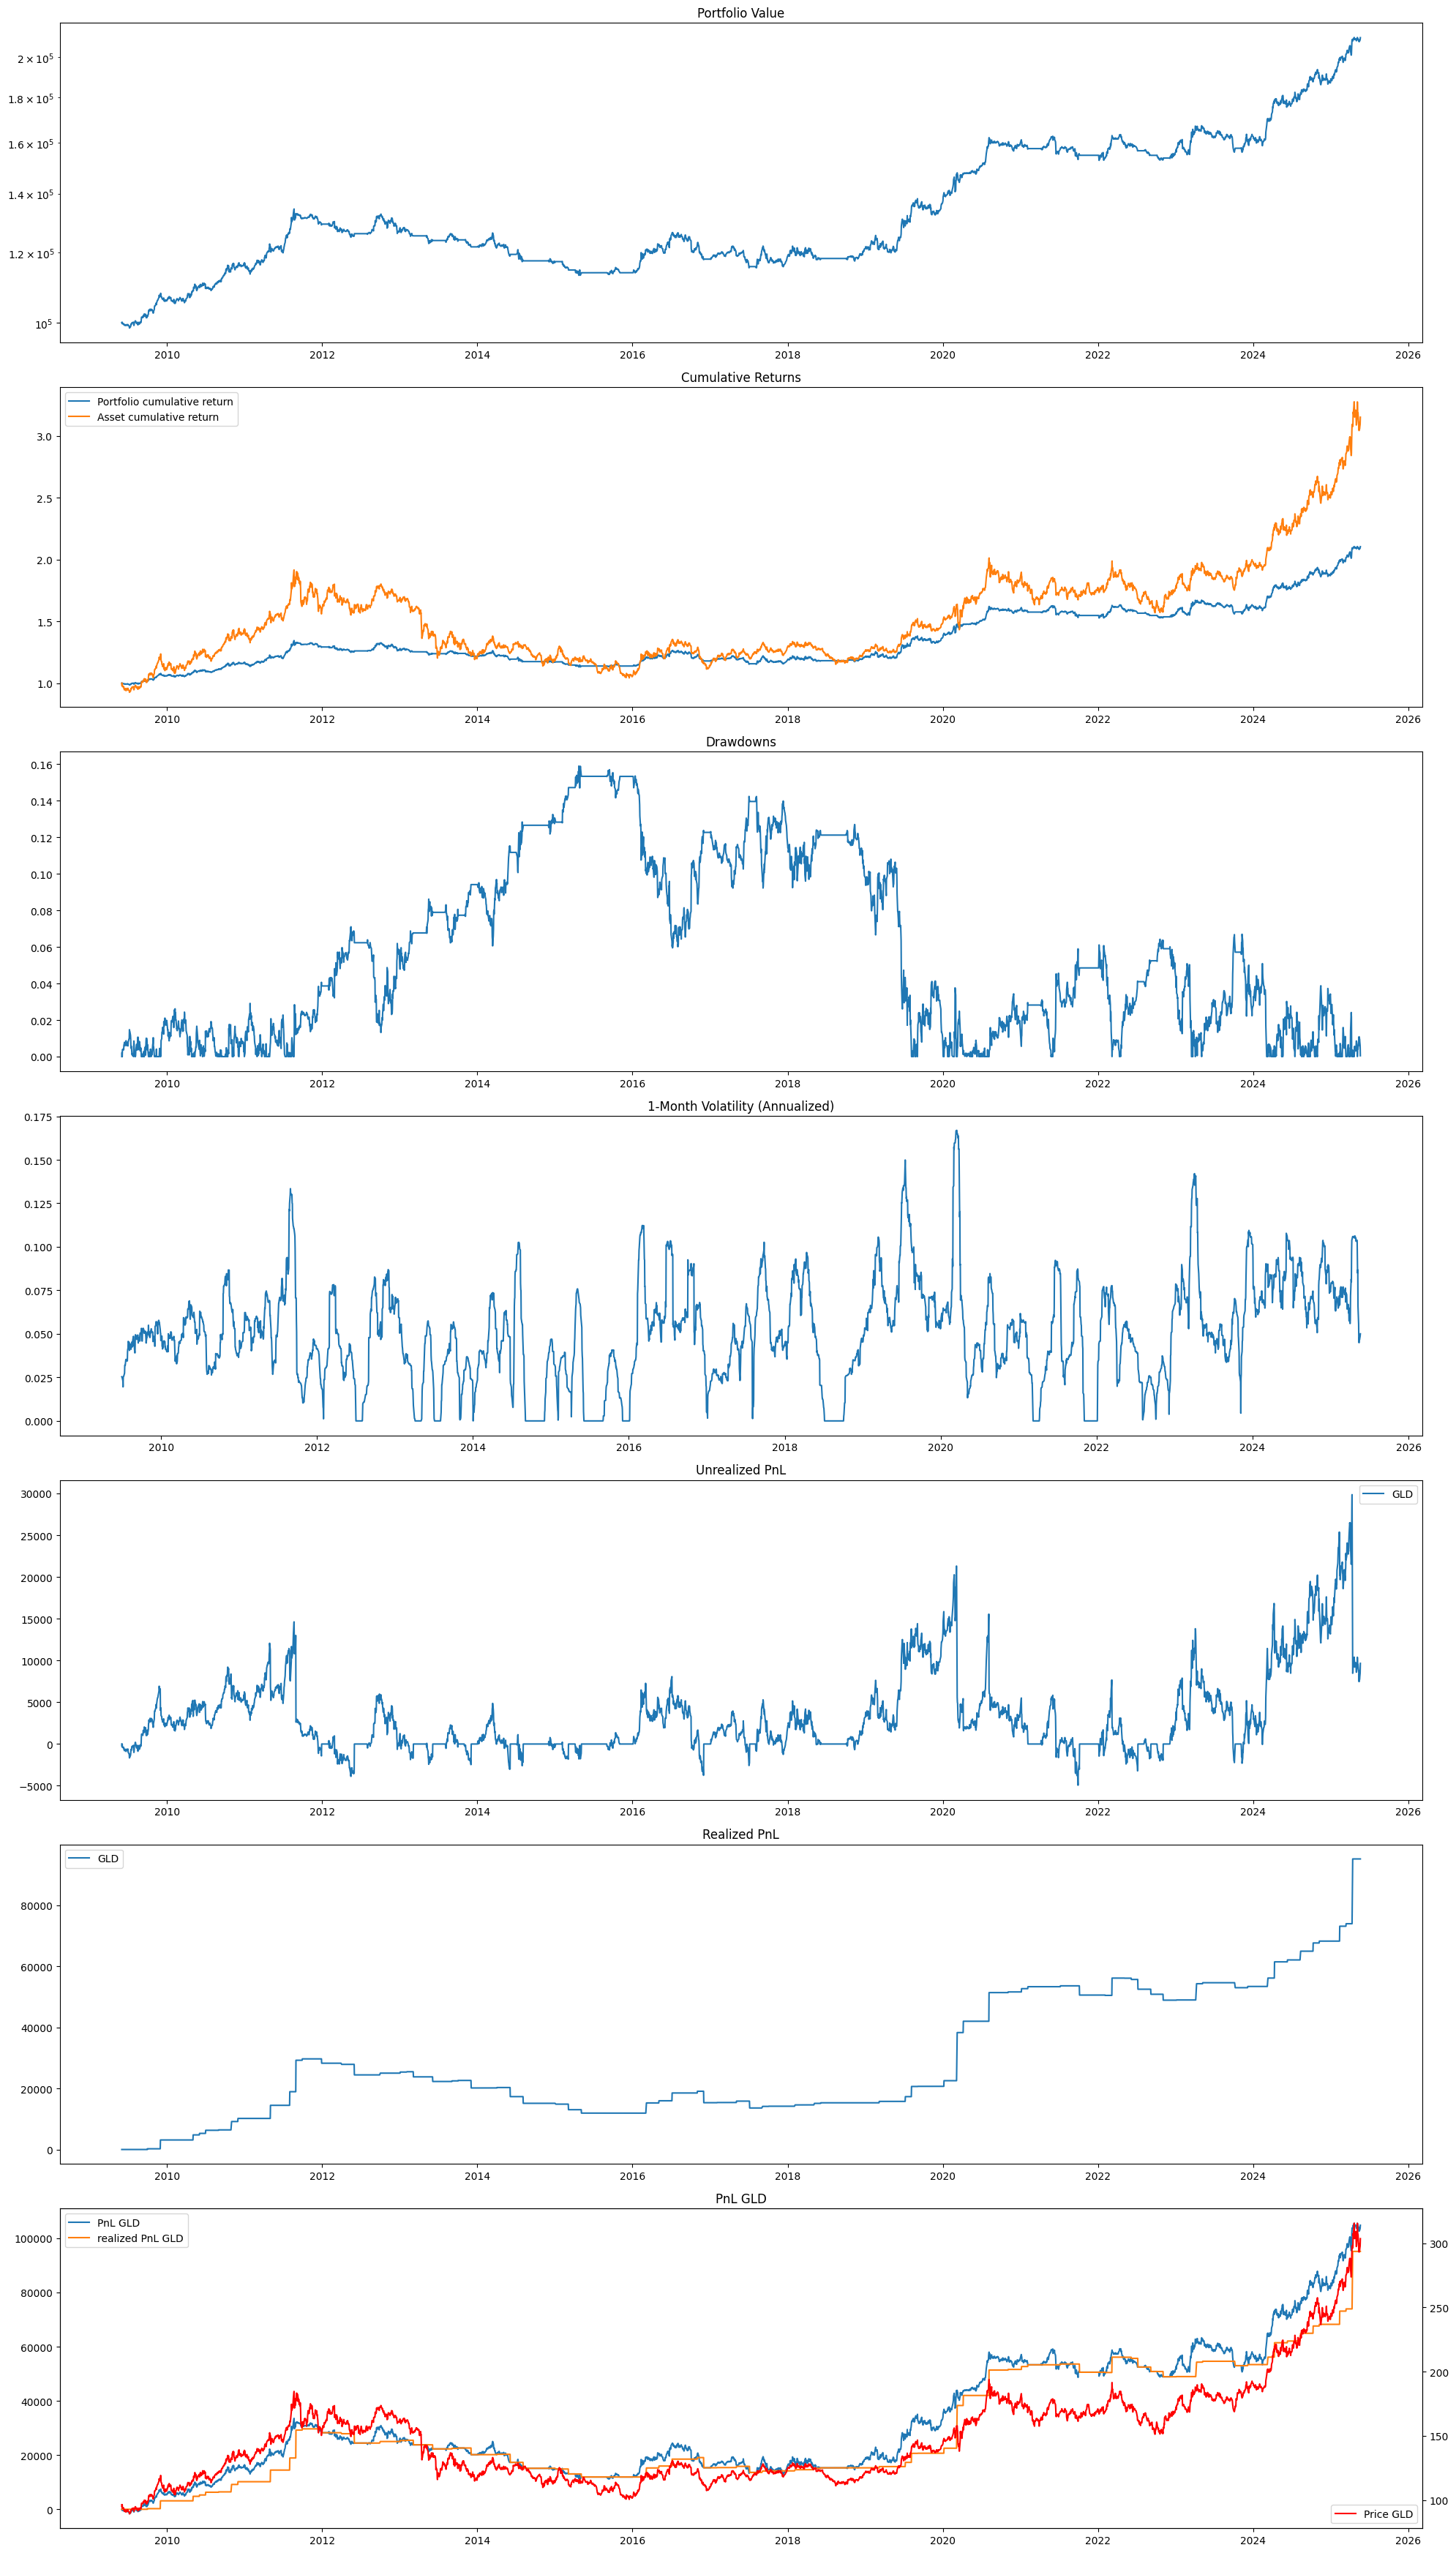

cagr: 0.05
volatility: 0.06
sharpe: 0.82
max_drawdown: 0.16
cumulative_returns: 1.10

-------------------------------------------
TLT


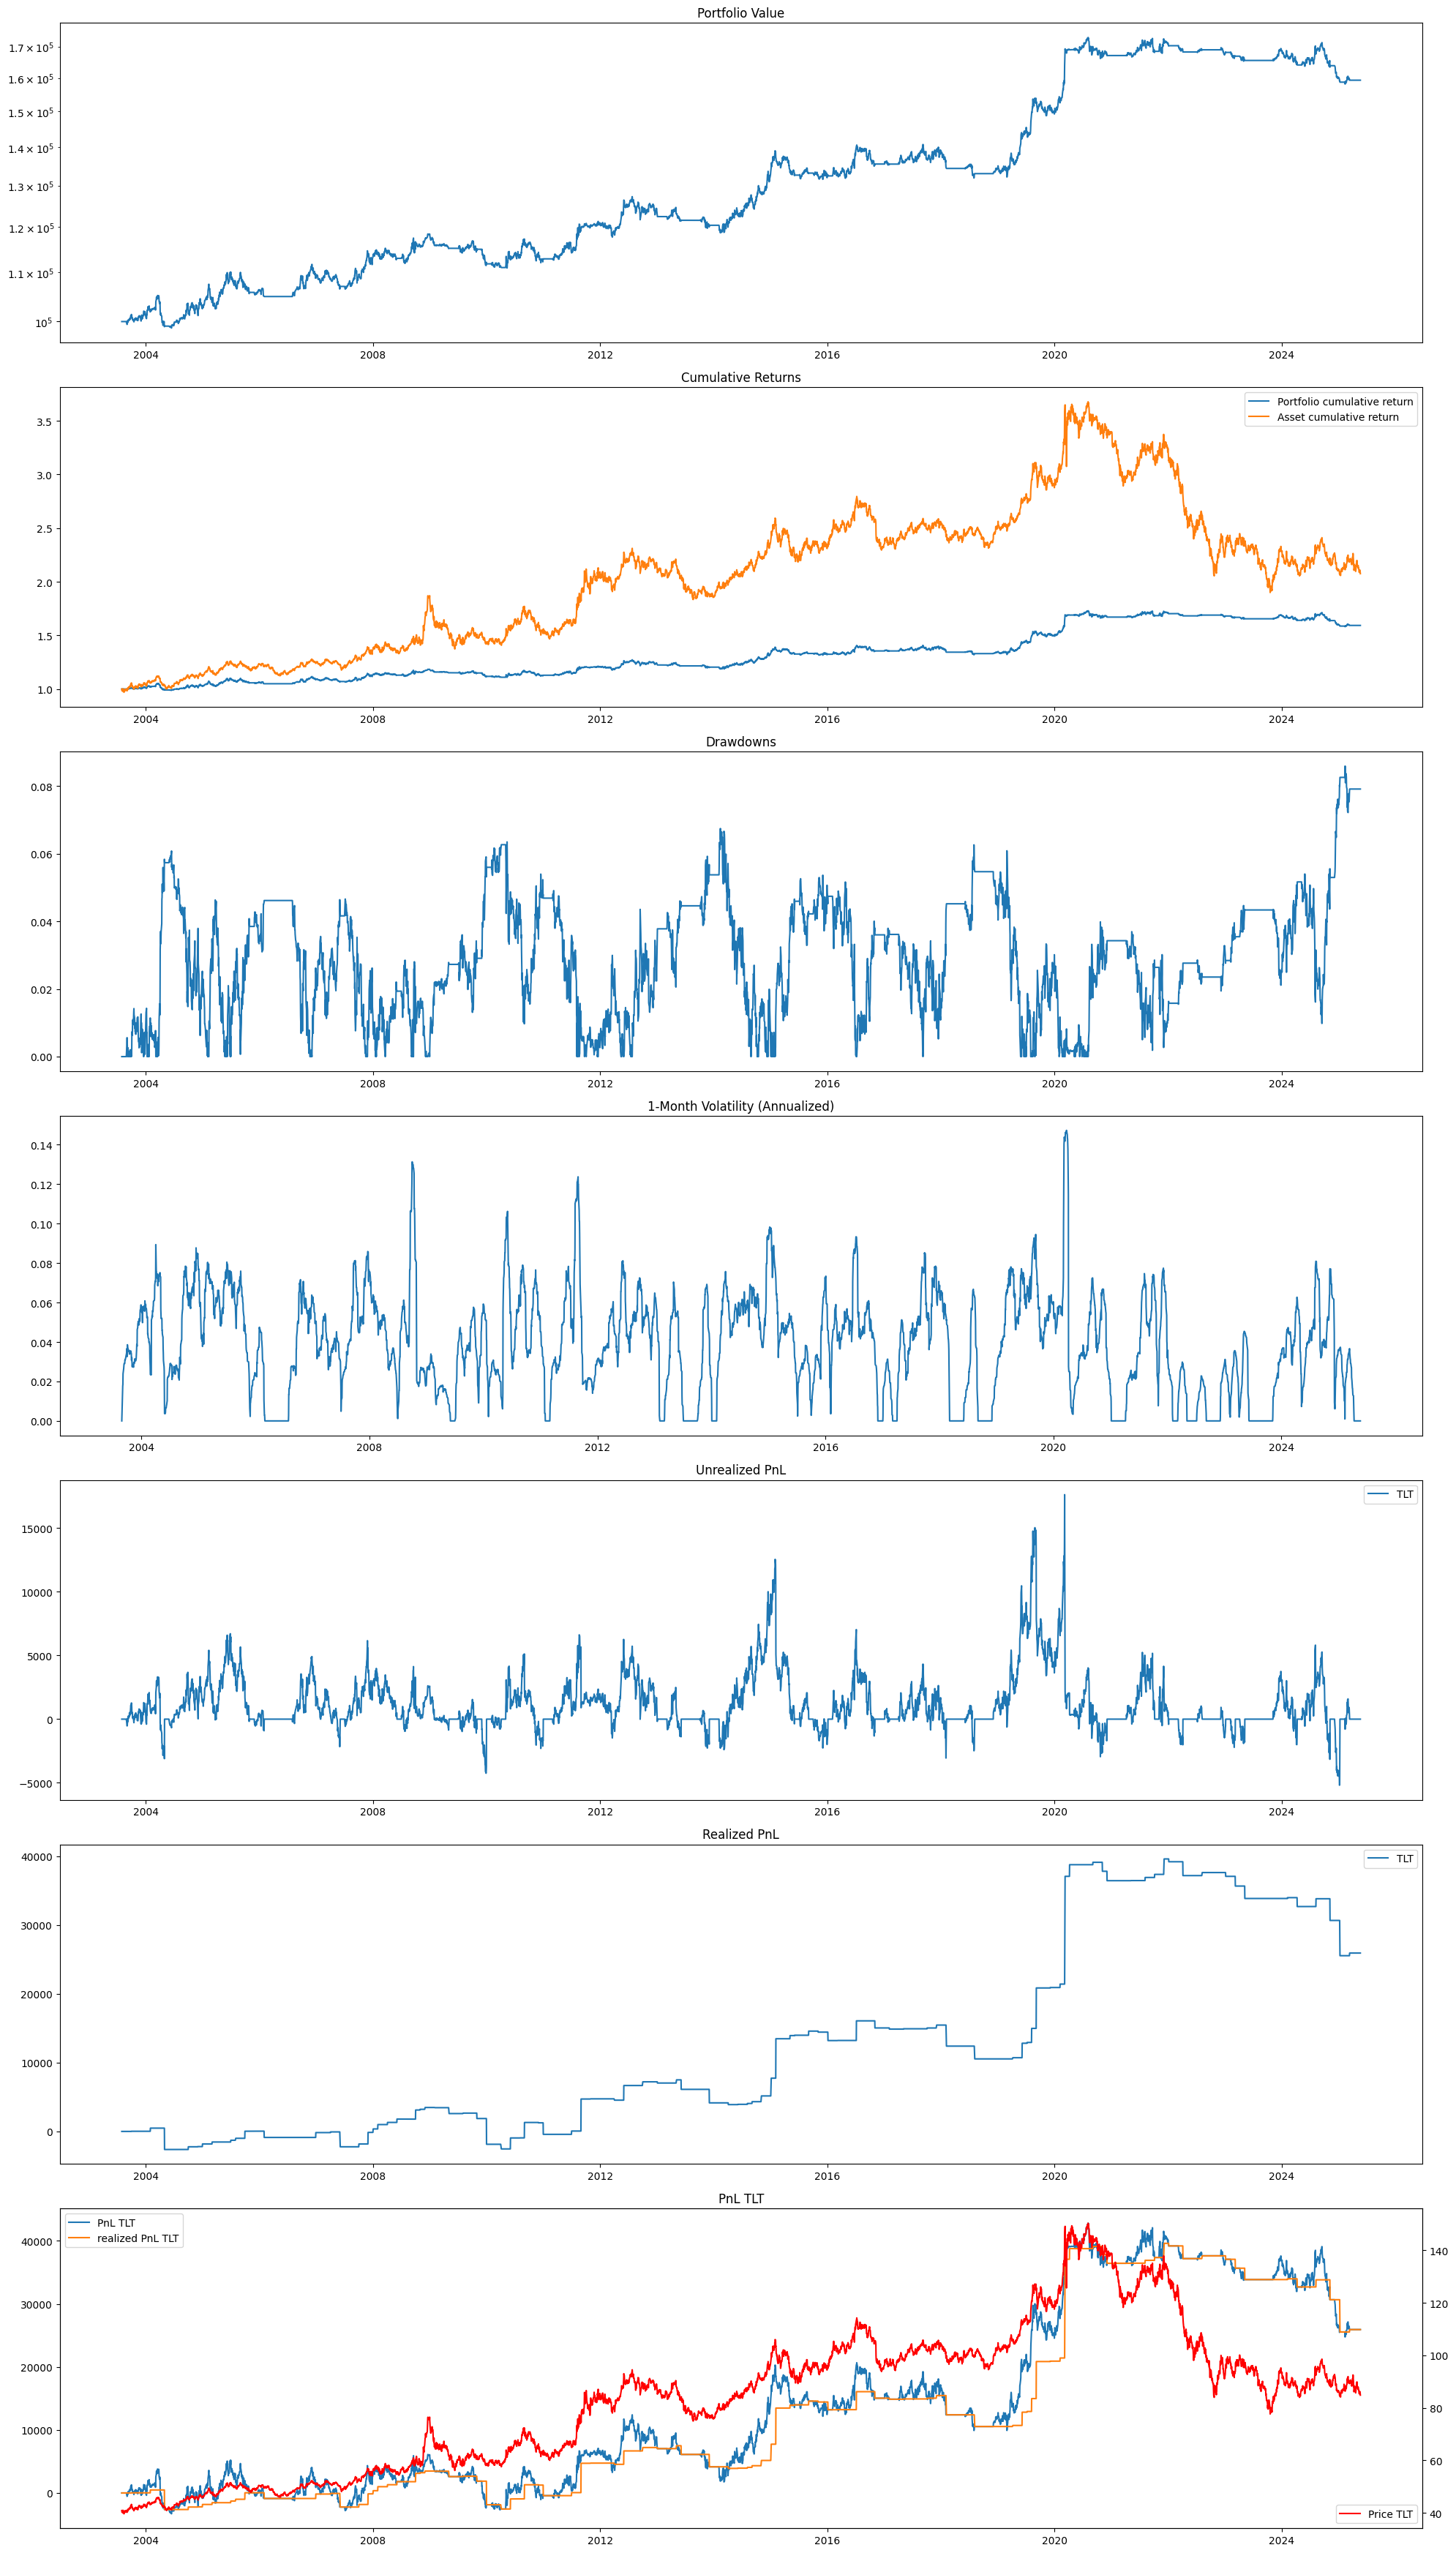

cagr: 0.02
volatility: 0.05
sharpe: 0.47
max_drawdown: 0.09
cumulative_returns: 0.59


In [9]:
for ticker in assets:
    print('\n-------------------------------------------')
    print(ticker)
    df = assets[ticker].data.copy()
    # print(df.columns)
    df = df[['open', 'high', 'low', 'close', 'adjclose', 'volume', 'dividends', 'vol_scaling_factor_pred']]
    df.dropna(inplace=True)
    
    btr = BackTester({ticker: df})
    btr.add_strategy(
        TrendVol,
        tickers=[ticker],
        price_data={ticker: df},
        rebalance_period=rebalance_period,
        lookback_periods=[21, 100, 200, 252],
        df_vol=df,
        vol_scaling_col='vol_scaling_factor_pred',
    )
    results = btr.backtest()
    btr.plot_results()
    for key in results:
        if key == 'returns': continue
        print(f"{key}: {results[key]:.2f}")
    
    # display(results['returns'].tail())

    assets[ticker].strategy_returns['TrendVol'] = results['returns']

## Allocation to Assets

### Covariance Matrix

In [10]:
from pypfopt.hierarchical_portfolio import HRPOpt
from pypfopt.plotting import plot_dendrogram
from pypfopt import risk_models



df_combined_returns = []
for ticker in assets:
    for strat in assets[ticker].strategy_returns:
        ticker_strat = f"{ticker}_{strat}"
        s = assets[ticker].strategy_returns[strat]['returns'].rename(ticker_strat)
        df_combined_returns.append(s)
df_combined_returns = pd.concat(df_combined_returns, axis=1, join='inner')

ewma_cov = risk_models.exp_cov(df_combined_returns, returns_data=True, span=covariance_matrix_lookback)
display(ewma_cov)


ledoit_wolf_cov = risk_models.CovarianceShrinkage(
    prices=df_combined_returns.iloc[-covariance_matrix_lookback:], 
    returns_data=True
).ledoit_wolf()
display(ledoit_wolf_cov)

cov = (ledoit_wolf_cov + ewma_cov) / 2
cov






,SPY_TrendVol,GLD_TrendVol,TLT_TrendVol
SPY_TrendVol,0.004215,0.000883,0.000029
GLD_TrendVol,0.000883,0.005958,0.000319
TLT_TrendVol,0.000029,0.000319,0.001156


,SPY_TrendVol,GLD_TrendVol,TLT_TrendVol
SPY_TrendVol,0.004949,0.001153,-0.000074
GLD_TrendVol,0.001153,0.005971,0.000529
TLT_TrendVol,-0.000074,0.000529,0.002078


,SPY_TrendVol,GLD_TrendVol,TLT_TrendVol
SPY_TrendVol,0.004582,0.001018,-0.000022
GLD_TrendVol,0.001018,0.005964,0.000424
TLT_TrendVol,-0.000022,0.000424,0.001617


### HRP

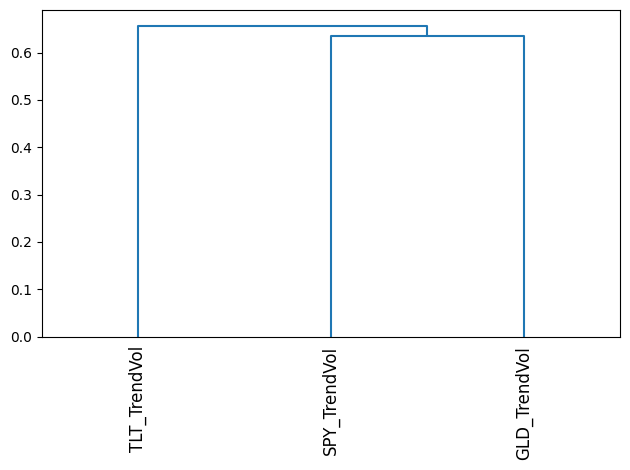

In [11]:
hrpopt = HRPOpt(
    # returns=df_combined_returns, 
    cov_matrix=cov
)
asset_allocation_weights = hrpopt.optimize()
plot_dendrogram(hrpopt)
plt.show()

## Target Portfolio

In [ ]:
capital_used = 0
for ticker in assets:
    df_data = assets[ticker].data.copy()
    df_target = pd.DataFrame()
    for period in lookback_periods:
        df_target[f'trend_{period}'] = df_data['close'] - df_data['close'].rolling(period).mean()
    df_target['trend_factor'] = 0
    for period in lookback_periods:
        df_target['trend_factor'] += np.where(df_target[f'trend_{period}'] > 0, 1, 0) * (1 / len(lookback_periods))
    df_target['vol_scaling_factor'] = df_data['vol_scaling_factor_pred']
    df_target['strategy_allocation'] = np.min([df_target['trend_factor'], df_target['vol_scaling_factor']], axis=0)
    df_target['curr_price'] = df_data['close']
    
    for ticker_strat in asset_allocation_weights:
        if ticker_strat.startswith(ticker):
            break
        
    strategy_allocation = df_target['strategy_allocation'].to_list()[-1]
    asset_allocation = asset_allocation_weights[ticker_strat]
    final_allocation = strategy_allocation * asset_allocation
    capital_allocated = capital * leverage * final_allocation
    capital_used += capital_allocated
    current_price = df_target['curr_price'].to_list()[-1]
    
    # target_position = int(capital_allocated / current_price)


    print(ticker)
    print(f'strategy_allocation = {strategy_allocation:.2%}')
    print(f'asset allocation    = {asset_allocation:.2%}')
    print(f'final allocation    = {final_allocation:.2%}')
    print(f'capital allocated:  = ${capital_allocated:.2f}')
    print(f'target position:    = {capital_allocated:.2f} / {current_price:.2f} = {target_position} shares')
    print('----------------------------------')

capital_allocated = max(0.0, capital - capital_used)
current_price = cash_asset['data']['close'].to_list()[-1]
target_position = int(capital_allocated / current_price)

print('SHV')
print(f'capital allocated:  = ${capital_allocated:.2f}')
print(f'target position:    = {capital_allocated:.2f} / {current_price:.2f} = {target_position} shares')
print('----------------------------------')


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,vol_forward,ret_forward,ATR,var_forward,VIX,vol_scaling_factor,vol_forward_pred,var_forward_pred,vol_scaling_factor_pred
Date,,,,,,,,,,,,,,,,,,,
1993-01-29,43.968750,43.968750,43.750000,43.937500,24.452524,1003200,0.0,0.0,0.0,NaN,NaN,0.015537,NaN,0.016266,12.420000,0.527980,NaN,NaN,NaN
1993-02-01,43.968750,44.250000,43.968750,44.250000,24.626427,480500,0.0,0.0,0.0,0.007112,0.126257,0.017618,0.007112,0.015941,12.330000,0.534882,0.092577,0.008571,0.768766
1993-02-02,44.218750,44.375000,44.125000,44.343750,24.678604,201300,0.0,0.0,0.0,0.002119,0.128059,0.001395,0.006934,0.016399,12.250000,0.524405,0.091502,0.008373,0.778011
1993-02-03,44.406250,44.843750,44.375000,44.812500,24.939484,529400,0.0,0.0,0.0,0.010571,0.123457,-0.005556,0.007315,0.015242,12.120000,0.550043,0.092170,0.008495,0.771848
1993-02-04,44.968750,45.093750,44.468750,45.000000,25.043823,531500,0.0,0.0,0.0,0.004184,0.144399,0.017373,0.007848,0.020851,12.290000,0.437015,0.095005,0.009026,0.751633
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-15,585.559998,590.969971,585.099976,590.460022,590.460022,71268100,0.0,0.0,0.0,0.004884,NaN,NaN,0.017528,NaN,17.830000,NaN,0.159751,0.025520,0.360039
2025-05-16,591.250000,594.500000,589.280029,594.200012,594.200012,76052100,0.0,0.0,0.0,0.006334,NaN,NaN,0.016661,NaN,17.240000,NaN,0.153444,0.023545,0.387649
2025-05-19,588.099976,595.539978,588.099976,594.849976,594.849976,68168500,0.0,0.0,0.0,0.001094,NaN,NaN,0.016189,NaN,18.139999,NaN,0.156617,0.024529,0.373721


SPY
strategy_allocation = 36.88%
asset allocation    = 19.42%
final allocation    = 7.16%
capital allocated:  = $14520.02
target position:    = 14520.02 / 589.72 = 0 shares
----------------------------------


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,vol_forward,ret_forward,ATR,var_forward,VIX,vol_scaling_factor,vol_forward_pred,var_forward_pred,vol_scaling_factor_pred
Date,,,,,,,,,,,,,,,,,,,
2004-11-18,44.430000,44.490002,44.070000,44.380001,44.380001,5992000,0.0,0.0,0.0,NaN,NaN,-0.009826,NaN,0.021859,NaN,0.445991,NaN,NaN,NaN
2004-11-19,44.490002,44.919998,44.470001,44.779999,44.779999,11655300,0.0,0.0,0.0,0.009013,NaN,-0.016240,0.012168,0.020894,NaN,0.469930,NaN,NaN,NaN
2004-11-22,44.750000,44.970001,44.740002,44.950001,44.950001,11996000,0.0,0.0,0.0,0.003796,NaN,-0.016313,0.011430,0.020816,NaN,0.471487,NaN,NaN,NaN
2004-11-23,44.880001,44.919998,44.720001,44.750000,44.750000,3169200,0.0,0.0,0.0,-0.004449,NaN,-0.017314,0.010816,0.021138,NaN,0.464091,NaN,NaN,NaN
2004-11-24,44.930000,45.049999,44.790001,45.049999,45.049999,6105100,0.0,0.0,0.0,0.006704,NaN,-0.017885,0.010486,0.020845,NaN,0.470903,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-15,294.100006,297.899994,293.750000,297.839996,297.839996,13497700,0.0,0.0,0.0,0.015964,NaN,NaN,0.021139,NaN,21.629999,NaN,0.183580,0.033702,0.248735
2025-05-16,292.619995,294.579987,291.779999,294.239990,294.239990,14173000,0.0,0.0,0.0,-0.012087,NaN,NaN,0.020765,NaN,21.469999,NaN,0.182085,0.033155,0.254574
2025-05-19,297.850006,298.579987,296.480011,298.029999,298.029999,11656300,0.0,0.0,0.0,0.012881,NaN,NaN,0.020450,NaN,21.370001,NaN,0.181042,0.032776,0.257299


GLD
strategy_allocation = nan%
asset allocation    = 14.92%
final allocation    = nan%
capital allocated:  = $nan
target position:    = nan / 304.71 = 0 shares
----------------------------------


,open,high,low,close,adjclose,volume,dividends,stock_splits,capital_gains,returns,vol_forward,ret_forward,ATR,var_forward,vol_scaling_factor,vol_forward_pred,var_forward_pred,vol_scaling_factor_pred
Date,,,,,,,,,,,,,,,,,,
2002-07-30,81.750000,81.900002,81.519997,81.519997,37.748489,6100,0.0,0.0,0.0,NaN,NaN,0.040470,NaN,0.015138,0.477185,NaN,NaN,NaN
2002-07-31,81.949997,82.800003,81.900002,82.529999,38.216198,29400,0.0,0.0,0.0,0.012390,0.119677,0.042892,0.015702,0.014322,0.503934,0.170355,0.029021,0.174126
2002-08-01,82.540001,83.019997,82.540001,83.000000,38.433857,25000,0.0,0.0,0.0,0.005695,0.119788,0.038521,0.014639,0.014349,0.503059,0.161565,0.026103,0.222727
2002-08-02,83.160004,84.099998,82.879997,83.849998,38.827442,52800,0.0,0.0,0.0,0.010241,0.120437,0.045357,0.014569,0.014505,0.497290,0.160986,0.025917,0.226224
2002-08-05,84.040001,84.440002,83.849998,84.220001,38.998787,61100,0.0,0.0,0.0,0.004413,0.120506,0.054132,0.013750,0.014522,0.496241,0.154209,0.023780,0.262937
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-15,85.629997,86.320000,85.480003,86.070000,86.070000,59448000,0.0,0.0,0.0,0.008790,NaN,NaN,0.011911,NaN,NaN,0.138990,0.019318,0.357867
2025-05-16,86.870003,86.889999,86.199997,86.300003,86.300003,31778200,0.0,0.0,0.0,0.002672,NaN,NaN,0.011600,NaN,NaN,0.136416,0.018609,0.378671
2025-05-19,84.910004,86.120003,84.830002,86.050003,86.050003,49361900,0.0,0.0,0.0,-0.002897,NaN,NaN,0.012066,NaN,NaN,0.140271,0.019676,0.350175


TLT
strategy_allocation = 0.00%
asset allocation    = 65.66%
final allocation    = 0.00%
capital allocated:  = $0.00
target position:    = 0.00 / 84.82 = 0 shares
----------------------------------
SHV
capital allocated:  = $0.00
target position:    = 0.00 / 115.78 = 0 shares
----------------------------------


## Live Portfolio Testing

CAGR:                   0.87%
Volatility:             10.45%
Sharpe Ratio:           0.08
Max Drawdown:          -3.21%
Total Returns:          0.08%
Total PnL:             $54.07


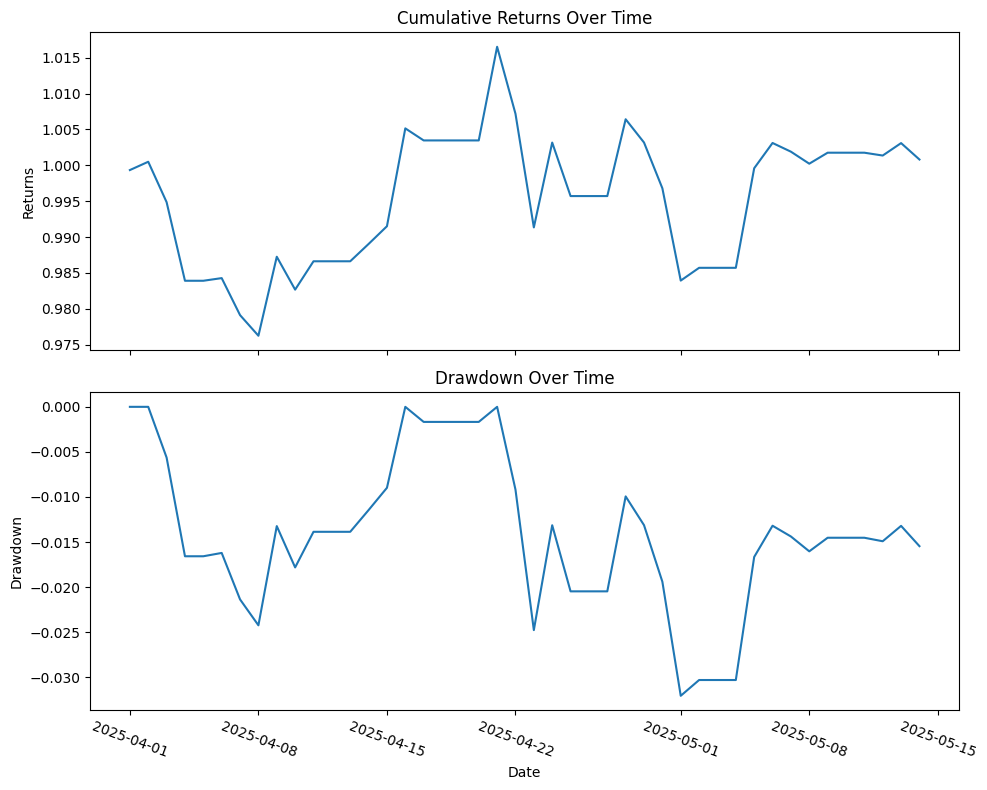

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def compute_portfolio_value(trades_df, price_data_dict):
    """
    Compute daily portfolio value given trades and price data.
    
    trades_df: DataFrame with columns ['date', 'ticker', 'quantity', 'price', 'fees']
    price_data_dict: dict mapping ticker -> DataFrame with index 'date' and column 'close'
    
    Returns:
        portfolio_value: Series indexed by date
    """
    # Ensure date types and sort
    trades = trades_df.copy()
    trades['date'] = pd.to_datetime(trades['date'])
    trades.sort_values('date', inplace=True)

    # Determine date index range
    all_dates = pd.date_range(
        start=trades['date'].min(), 
        end=max(df.index.max() for df in price_data_dict.values()),
        freq='D'
    )
    
    # Initialize cash flow and holdings
    cash_flows = pd.Series(0.0, index=all_dates)
    holdings = {ticker: pd.Series(0.0, index=all_dates) for ticker in price_data_dict if ticker != 'CASH'}
    invested_capital = pd.Series(0.0, index=all_dates)
    
    # Process trades
    for _, row in trades.iterrows():
        dt = row['date']
        tk = row['ticker']
        qty = row['quantity']
        price = row['price']
        fees = row['fees']
        
        if tk == 'CASH':
            cash_flows.loc[dt] += qty
            invested_capital[dt:] += qty
        else:
            # Update holdings from this date onward
            holdings[tk].loc[dt:] += qty
            # Cash change: buying (positive qty) -> outflow; selling (negative qty) -> inflow
            cash_flows.loc[dt] += -qty * price - fees
    
    # Compute cumulative cash
    cash = cash_flows.cumsum()
    
    # Compute daily holdings value
    holdings_value = pd.Series(0.0, index=all_dates)
    for tk, pos in holdings.items():
        # Align prices
        # prices = price_data_dict[tk].reindex(all_dates)['close'].fillna(method='ffill')
        prices = price_data_dict[tk].reindex(all_dates)['close'].ffill()
        holdings_value += pos * prices
    
    # Total portfolio value
    portfolio_value = cash + holdings_value
    return portfolio_value, invested_capital

def compute_performance_metrics(portfolio_value, invested_capital, trading_days=252):
    """
    Compute performance metrics: CAGR, volatility, Sharpe ratio, max drawdown
    """
    cumulative_returns = portfolio_value / invested_capital

    # Daily returns
    daily_returns = cumulative_returns.pct_change().dropna()
    
    # CAGR
    total_days = (cumulative_returns.index[-1] - cumulative_returns.index[0]).days
    cagr = (cumulative_returns.iloc[-1] / cumulative_returns.iloc[0]) ** (trading_days / total_days) - 1
    
    # Volatility (annualized)
    vol = daily_returns.std() * np.sqrt(trading_days)
    
    # Sharpe ratio (assumes risk-free rate = 0)
    sharpe = cagr / vol
    
    # Max drawdown
    rolling_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - rolling_max) / rolling_max
    max_dd = drawdown.min()

    print(f'CAGR:                   {cagr:.2%}')
    print(f'Volatility:             {vol:.2%}')
    print(f'Sharpe Ratio:           {sharpe:.2f}')
    print(f'Max Drawdown:          -{-max_dd:.2%}')
    print(f'Total Returns:          {portfolio_value.iloc[-1] / invested_capital.iloc[-1] - 1:.2%}')
    print(f'Total PnL:             ${portfolio_value.iloc[-1] - invested_capital.iloc[-1]:.2f}')
    
    
    return {
        'CAGR': cagr,
        'Volatility': vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd
    }

def plot_portfolio_and_drawdown(portfolio_value, invested_capital):
    """
    Plot portfolio value and drawdown
    """
    cumulative_returns = portfolio_value / invested_capital

    # Compute drawdown
    rolling_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - rolling_max) / rolling_max
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 8))
    
    ax1.plot(cumulative_returns.index, cumulative_returns.values)
    ax1.set_title('Cumulative Returns Over Time')
    ax1.set_ylabel('Returns')
    
    ax2.plot(drawdown.index, drawdown.values)
    ax2.set_title('Drawdown Over Time')
    ax2.set_ylabel('Drawdown')
    ax2.set_xlabel('Date')
    plt.setp(ax2.get_xticklabels(), rotation=-20)
    
    plt.tight_layout()
    plt.show()

# Example usage:
trades_df = pd.read_excel('portfolio_tracker.xlsx')
# trades_df = trades_df.loc[trades_df['ticker'].isin(['SPY', 'TLT', 'GLD', 'SHV', 'CASH'])]
price_data_dict = {
    'SPY': pd.read_pickle(f'./data/raw/price/SPY_{current_date}.pkl'),
    'TLT': pd.read_pickle(f'./data/raw/price/TLT_{current_date}.pkl'),
    'GLD': pd.read_pickle(f'./data/raw/price/GLD_{current_date}.pkl'),
    'SHV': pd.read_pickle(f'./data/raw/price/SHV_{current_date}.pkl'),
    'PPLT': pd.read_pickle(f'./data/raw/price/PPLT_{current_date}.pkl'),
    'URA': pd.read_pickle(f'./data/raw/price/URA_{current_date}.pkl'),

}
port_val, invested_cap = compute_portfolio_value(trades_df, price_data_dict)
metrics = compute_performance_metrics(port_val, invested_cap)
plot_portfolio_and_drawdown(port_val, invested_cap)
# for key in metrics:
#     print(f'{key}: {metrics[key]:.2f}')


